In [1]:
from pathlib import Path
import json
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
)

ROOT = Path("/Users/mh/Downloads/Mini Project/202604/anomaly_detection_v1")

for d in [
    ROOT / "runs",
    ROOT / "notebooks",
    ROOT / "src",
    ROOT / "data",
]:
    d.mkdir(parents=True, exist_ok=True)

registry_path = ROOT / "runs" / "registry.csv"
if not registry_path.exists():
    registry_path.write_text(
        "run_id,run_name,timestamp,model,n_rows,n_features,label_available,pr_auc,precision,recall,f1,notes\n",
        encoding="utf-8"
    )

print("Project ready:", ROOT)

Project ready: /Users/mh/Downloads/Mini Project/202604/anomaly_detection_v1


In [2]:
candidates = [
    ROOT / "data" / "server_metrics.csv",
    ROOT / "server_metrics.csv",
    ROOT / "data" / "raw" / "server_metrics.csv",
]

csv_path = None
for p in candidates:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("server_metrics.csv が見つかりません。data/ または project root に置いてください。")

df = pd.read_csv(csv_path)
df.columns = [c.strip().lower() for c in df.columns]

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Loaded: /Users/mh/Downloads/Mini Project/202604/anomaly_detection_v1/data/server_metrics.csv
Shape: (2000, 4)
Columns: ['timestamp', 'cpu_pct', 'latency_ms', 'label']


,timestamp,cpu_pct,latency_ms,label
0,2026-01-01 00:00:00,71.158460,48.192196,1
1,2026-01-01 00:01:00,26.923681,47.358306,0
2,2026-01-01 00:02:00,32.338619,51.779672,0
3,2026-01-01 00:03:00,32.952590,51.072866,0
4,2026-01-01 00:04:00,24.321418,44.468096,0


In [3]:
time_candidates = ["timestamp", "time", "datetime", "date", "ds", "t"]
label_candidates = ["label", "is_anomaly", "anomaly", "target", "y", "class"]

time_col = next((c for c in time_candidates if c in df.columns), None)
label_col = next((c for c in label_candidates if c in df.columns), None)

if time_col is not None:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col).reset_index(drop=True)

if label_col is not None:
    # なるべく頑丈に 0/1 化
    raw = df[label_col]
    if raw.dtype == object:
        y = (
            raw.astype(str)
            .str.strip()
            .str.lower()
            .map({
                "1": 1, "0": 0,
                "true": 1, "false": 0,
                "yes": 1, "no": 0,
                "anomaly": 1, "normal": 0
            })
        )
        # mapできなかったものは numeric 化を試す
        y = y.fillna(pd.to_numeric(raw, errors="coerce"))
        y = y.fillna(0).astype(int)
    else:
        y = pd.to_numeric(raw, errors="coerce").fillna(0).astype(int)
else:
    y = None

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if label_col in numeric_cols:
    numeric_cols.remove(label_col)

print("time_col :", time_col)
print("label_col:", label_col)
print("numeric_cols:", numeric_cols)
print("label available:", y is not None)

time_col : timestamp
label_col: label
numeric_cols: ['cpu_pct', 'latency_ms']
label available: True


In [4]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_pct,2000.0,34.529894,11.977516,10.644371,26.482519,34.070918,39.078628,100.000000
latency_ms,2000.0,56.266001,36.183925,35.009644,47.522804,51.390611,55.077986,395.178918


In [5]:
work = df.copy()

for col in numeric_cols:
    work[f"{col}_diff1"] = work[col].diff().fillna(0)

feature_cols = numeric_cols + [f"{c}_diff1" for c in numeric_cols]

X = work[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("n_features:", len(feature_cols))
print(feature_cols)
X.head()

n_features: 4
['cpu_pct', 'latency_ms', 'cpu_pct_diff1', 'latency_ms_diff1']


,cpu_pct,latency_ms,cpu_pct_diff1,latency_ms_diff1
0,71.158460,48.192196,0.000000,0.000000
1,26.923681,47.358306,-44.234780,-0.833890
2,32.338619,51.779672,5.414938,4.421366
3,32.952590,51.072866,0.613971,-0.706806
4,24.321418,44.468096,-8.631172,-6.604770


In [6]:
X_values = X.values.astype(float)

means = X_values.mean(axis=0)
stds = X_values.std(axis=0)
stds = np.where(stds == 0, 1e-9, stds)

z = (X_values - means) / stds
z_score = np.max(np.abs(z), axis=1)

# ラベルありなら後で最適閾値化、なければ固定閾値
default_z_threshold = 3.0
z_pred_default = (z_score >= default_z_threshold).astype(int)

print("Z-score ready")
print("default threshold:", default_z_threshold)

Z-score ready
default threshold: 3.0


In [7]:
#Cell 7: Isolation Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
)

iso.fit(X_scaled)

# score_samples は「大きいほど normal」寄りなので符号反転
iso_score = -iso.score_samples(X_scaled)

# ラベルありなら後で最適閾値化、なければ95パーセンタイル
iso_default_threshold = np.percentile(iso_score, 95)
iso_pred_default = (iso_score >= iso_default_threshold).astype(int)

print("Isolation Forest ready")
print("default threshold:", iso_default_threshold)

Isolation Forest ready
default threshold: 0.5743259728423932


In [8]:
#Cell 8: ラベルがある場合の評価関数
def best_threshold_from_scores(y_true, scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return None, None

    f1s = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-12)
    best_idx = int(np.argmax(f1s))
    return float(thresholds[best_idx]), {
        "precision": float(precisions[:-1][best_idx]),
        "recall": float(recalls[:-1][best_idx]),
        "f1": float(f1s[best_idx]),
    }

def evaluate_with_labels(y_true, scores, model_name):
    threshold, best_metrics = best_threshold_from_scores(y_true, scores)
    if threshold is None:
        return None

    pred = (scores >= threshold).astype(int)

    return {
        "model": model_name,
        "threshold": threshold,
        "pr_auc": float(average_precision_score(y_true, scores)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pred": pred,
    }

In [9]:
#Cell 9: 評価またはスコア確認
if y is not None:
    z_eval = evaluate_with_labels(y, z_score, "zscore")
    iso_eval = evaluate_with_labels(y, iso_score, "isolation_forest")

    metrics_table = pd.DataFrame([
        {k: v for k, v in z_eval.items() if k != "pred"},
        {k: v for k, v in iso_eval.items() if k != "pred"},
    ])

    display(metrics_table)

    best_eval = max([z_eval, iso_eval], key=lambda d: d["f1"])
    best_model_name = best_eval["model"]
    best_pred = best_eval["pred"]
    best_score = z_score if best_model_name == "zscore" else iso_score
else:
    metrics_table = None
    best_model_name = "isolation_forest"
    best_pred = iso_pred_default
    best_score = iso_score

    top_anomalies = work.copy()
    top_anomalies["anomaly_score"] = best_score
    top_anomalies = top_anomalies.sort_values("anomaly_score", ascending=False).head(20)

    print("No label column found. Saved outputs will be score-based only.")
    display(top_anomalies[[c for c in [time_col] + numeric_cols if c is not None]].head())

,model,threshold,pr_auc,precision,recall,f1
0,zscore,3.845816,0.635098,0.555556,0.70,0.619469
1,isolation_forest,0.621326,0.759934,0.897059,0.61,0.726190


In [10]:
#Cell 10: errors.tsv 用データ作成
result_df = work.copy()
result_df["anomaly_score"] = best_score
result_df["pred"] = best_pred

if y is not None:
    result_df["y_true"] = y.values

    fp = result_df[(result_df["y_true"] == 0) & (result_df["pred"] == 1)].copy()
    fn = result_df[(result_df["y_true"] == 1) & (result_df["pred"] == 0)].copy()

    fp["error_type"] = "FP"
    fn["error_type"] = "FN"

    errors_df = pd.concat([fp, fn], axis=0).sort_values("anomaly_score", ascending=False)
else:
    errors_df = result_df.sort_values("anomaly_score", ascending=False).head(50).copy()
    errors_df["error_type"] = "TOP_SCORED"

print("best_model_name:", best_model_name)
print("errors rows:", len(errors_df))
errors_df.head()

best_model_name: isolation_forest
errors rows: 46


,timestamp,cpu_pct,latency_ms,label,cpu_pct_diff1,latency_ms_diff1,anomaly_score,pred,y_true,error_type
621,2026-01-01 10:21:00,63.354151,49.360931,0,1.378695,-342.473176,0.656568,1,0,FP
1259,2026-01-01 20:59:00,21.451449,45.099354,0,-6.634991,-342.844695,0.643813,1,0,FP
829,2026-01-01 13:49:00,17.402758,57.686338,0,-55.800919,16.613717,0.636978,1,0,FP
1494,2026-01-02 00:54:00,31.273609,56.930477,0,-19.714691,-214.142409,0.626090,1,0,FP
521,2026-01-01 08:41:00,34.969238,60.945338,0,0.219242,-334.233581,0.625904,1,0,FP


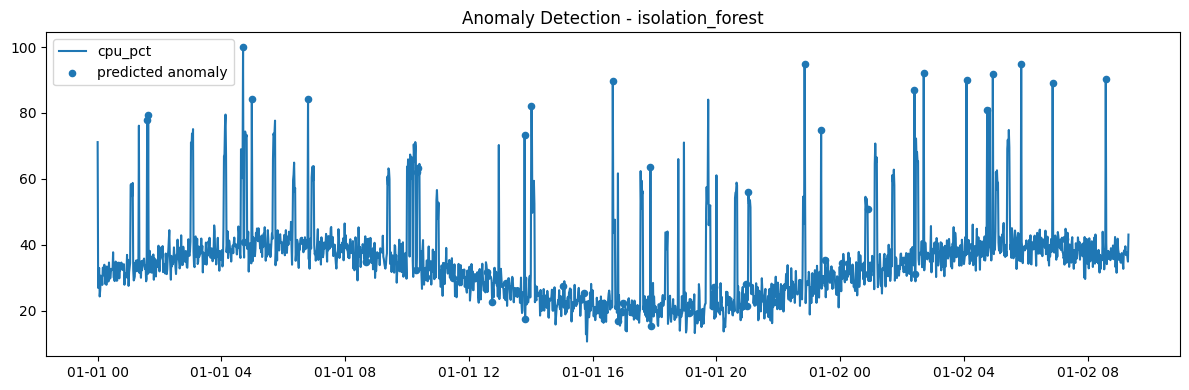

In [11]:
#Cell 11: 可視化

plot_col = numeric_cols[0] if len(numeric_cols) > 0 else None

if plot_col is not None:
    plt.figure(figsize=(12, 4))
    x_axis = work[time_col] if time_col is not None else np.arange(len(work))

    plt.plot(x_axis, work[plot_col], label=plot_col)

    anomaly_idx = np.where(best_pred == 1)[0]
    plt.scatter(
        x_axis.iloc[anomaly_idx] if time_col is not None else anomaly_idx,
        work.iloc[anomaly_idx][plot_col],
        s=20,
        label="predicted anomaly"
    )

    plt.title(f"Anomaly Detection - {best_model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
#Cell 12: run 保存

ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_name = "anomaly_detection_minimal_v1"
run_id = f"{ts}__{run_name}"

RUN_DIR = ROOT / "runs" / run_id
RUN_DIR.mkdir(parents=True, exist_ok=True)

run_cfg = {
    "project": "anomaly_detection_v1",
    "run_name": run_name,
    "input_csv": str(csv_path),
    "time_col": time_col,
    "label_col": label_col,
    "numeric_cols": numeric_cols,
    "feature_cols": feature_cols,
    "models": ["zscore", "isolation_forest"],
}

if y is not None:
    chosen_metrics = {
        "model": best_model_name,
        "n_rows": int(len(work)),
        "n_features": int(len(feature_cols)),
        "label_available": True,
        "pr_auc": float(metrics_table.loc[metrics_table["model"] == best_model_name, "pr_auc"].iloc[0]),
        "precision": float(metrics_table.loc[metrics_table["model"] == best_model_name, "precision"].iloc[0]),
        "recall": float(metrics_table.loc[metrics_table["model"] == best_model_name, "recall"].iloc[0]),
        "f1": float(metrics_table.loc[metrics_table["model"] == best_model_name, "f1"].iloc[0]),
    }
else:
    chosen_metrics = {
        "model": best_model_name,
        "n_rows": int(len(work)),
        "n_features": int(len(feature_cols)),
        "label_available": False,
        "pr_auc": None,
        "precision": None,
        "recall": None,
        "f1": None,
    }

(RUN_DIR / "run_cfg.json").write_text(json.dumps(run_cfg, indent=2), encoding="utf-8")
(RUN_DIR / "metrics.json").write_text(json.dumps(chosen_metrics, indent=2), encoding="utf-8")

result_df.to_csv(RUN_DIR / "train_log.tsv", sep="\t", index=False, encoding="utf-8")
errors_df.to_csv(RUN_DIR / "errors.tsv", sep="\t", index=False, encoding="utf-8")

row = pd.DataFrame([{
    "run_id": run_id,
    "run_name": run_name,
    "timestamp": ts,
    "model": chosen_metrics["model"],
    "n_rows": chosen_metrics["n_rows"],
    "n_features": chosen_metrics["n_features"],
    "label_available": chosen_metrics["label_available"],
    "pr_auc": chosen_metrics["pr_auc"],
    "precision": chosen_metrics["precision"],
    "recall": chosen_metrics["recall"],
    "f1": chosen_metrics["f1"],
    "notes": "minimal practical anomaly detection"
}])

row.to_csv(registry_path, mode="a", header=False, index=False, encoding="utf-8")

print("✅ Saved:", RUN_DIR)
print(json.dumps(chosen_metrics, indent=2))

✅ Saved: /Users/mh/Downloads/Mini Project/202604/anomaly_detection_v1/runs/20260429_173456__anomaly_detection_minimal_v1
{
  "model": "isolation_forest",
  "n_rows": 2000,
  "n_features": 4,
  "label_available": true,
  "pr_auc": 0.7599342770912577,
  "precision": 0.8970588235294118,
  "recall": 0.61,
  "f1": 0.7261904761904762
}
